# Predicting heart disease using ML
This notebook uses various python based ML and data science libraries in an attempt to 
build a ML model capable of predicting whether or not someone has heart disease based
on their medical attributes

Approach:
1. Problem definition
2. Data
3. Evaluation
4. Features
5. Modeling
6. Experimentation

## 1. Problem definition
>Given clinical parameters about a patient, can we predict whether or not they have heart disease
> Data: https://archive.ics.uci.edu/dataset/45/heart+disease

## 2. Data : Given below

## 3. Evaluation
> If we can reach a 95% accuracy at predicting whether or not a patient has heart disease during the proof of concept, we'll pursue the project

## 4. Features
This is where you'll get different information about each of the features in your data

**Create a data dictionary** 
* id (Unique id for each patient)
* age (Age of the patient in years)
* origin (place of study)
* sex (Male/Female)
* cp chest pain type ([typical angina, atypical angina, non-anginal, asymptomatic])
* trestbps resting blood pressure (resting blood pressure (in mm Hg on admission to the hospital))
* chol (serum cholesterol in mg/dl)
* fbs (if fasting blood sugar > 120 mg/dl)
* restecg (resting electrocardiographic results)
* -- Values: [normal, stt abnormality, lv hypertrophy]
* thalach: maximum heart rate achieved
* exang: exercise-induced angina (True/ False)
* oldpeak: ST depression induced by exercise relative to rest
* slope: the slope of the peak exercise ST segment
* ca: number of major vessels (0-3) colored by fluoroscopy
* thal: [normal; fixed defect; reversible defect]
* num: the predicted attribute

# Preparing the tools
We will use pandas, matplotlib, and numpy for data analysis and manipulation

In [1]:
#Import tools
#Regular explorartory data analysus and plotting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#make plots inside the notebook
%matplotlib inline

#Models from sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

#model evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve

## Load data

In [2]:
df = pd.read_csv("./heart-disease.csv")
df.head(),df.shape

(   age  sex  cp  trestbps  chol  fbs  ...  exang  oldpeak  slope  ca  thal  target
0   63    1   3       145   233    1  ...      0      2.3      0   0     1       1
1   37    1   2       130   250    0  ...      0      3.5      0   0     2       1
2   41    0   1       130   204    0  ...      0      1.4      2   0     2       1
3   56    1   1       120   236    0  ...      0      0.8      2   0     2       1
4   57    0   0       120   354    0  ...      1      0.6      2   0     2       1

[5 rows x 14 columns], (303, 14))

## Data exploration (Exploratory data analysis or EDA)

The goal is to become a subject matter expert on the dataset

1. What questions are you trying to solve?
2. What kind of data do we have and how do we treat different types?
3. What's missing from the data and how do you deal with it?
4. Where are the outliers and why should you care about them?
5. How can we add, change or remove features to get more out of data?


In [3]:
#Find out how many of each class there are
df.target.value_counts()

target
1    165
0    138
Name: count, dtype: int64

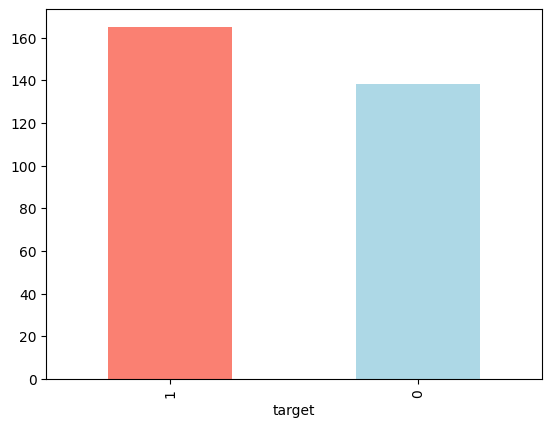

In [4]:
df["target"].value_counts().plot(kind="bar",color=["salmon","lightblue"])
plt.show()

In [5]:
df.info() #What type of columns, are there any missing values?

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [6]:
df.isna().sum() #Is there a null data in the dataset?

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [7]:
df.describe()

              age         sex          cp  ...          ca        thal      target
count  303.000000  303.000000  303.000000  ...  303.000000  303.000000  303.000000
mean    54.366337    0.683168    0.966997  ...    0.729373    2.313531    0.544554
std      9.082101    0.466011    1.032052  ...    1.022606    0.612277    0.498835
min     29.000000    0.000000    0.000000  ...    0.000000    0.000000    0.000000
25%     47.500000    0.000000    0.000000  ...    0.000000    2.000000    0.000000
50%     55.000000    1.000000    1.000000  ...    0.000000    2.000000    1.000000
75%     61.000000    1.000000    2.000000  ...    1.000000    3.000000    1.000000
max     77.000000    1.000000    3.000000  ...    4.000000    3.000000    1.000000

[8 rows x 14 columns]

### Heart Disease Frequency according to Sex

In [8]:
df["sex"].value_counts()

sex
1    207
0     96
Name: count, dtype: int64

In [9]:
# Compare target column with sex column
pd.crosstab(df.target,df.sex)

sex      0    1
target         
0       24  114
1       72   93

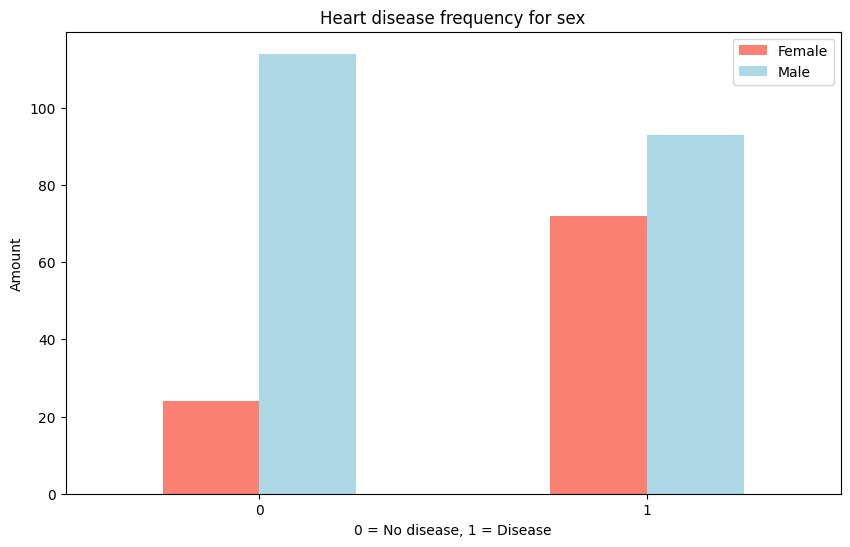

In [10]:
# Create a plot of crosstab
pd.crosstab(df.target,df.sex).plot(kind="bar",figsize=(10,6), color=["salmon","lightblue"])
plt.title("Heart disease frequency for sex")
plt.xlabel("0 = No disease, 1 = Disease")
plt.ylabel("Amount")
plt.legend(["Female","Male"]);
plt.xticks(rotation=0)
plt.show()

In [11]:
df.head()

   age  sex  cp  trestbps  chol  fbs  ...  exang  oldpeak  slope  ca  thal  target
0   63    1   3       145   233    1  ...      0      2.3      0   0     1       1
1   37    1   2       130   250    0  ...      0      3.5      0   0     2       1
2   41    0   1       130   204    0  ...      0      1.4      2   0     2       1
3   56    1   1       120   236    0  ...      0      0.8      2   0     2       1
4   57    0   0       120   354    0  ...      1      0.6      2   0     2       1

[5 rows x 14 columns]

### Age vs Max Heart Rate for heart disease

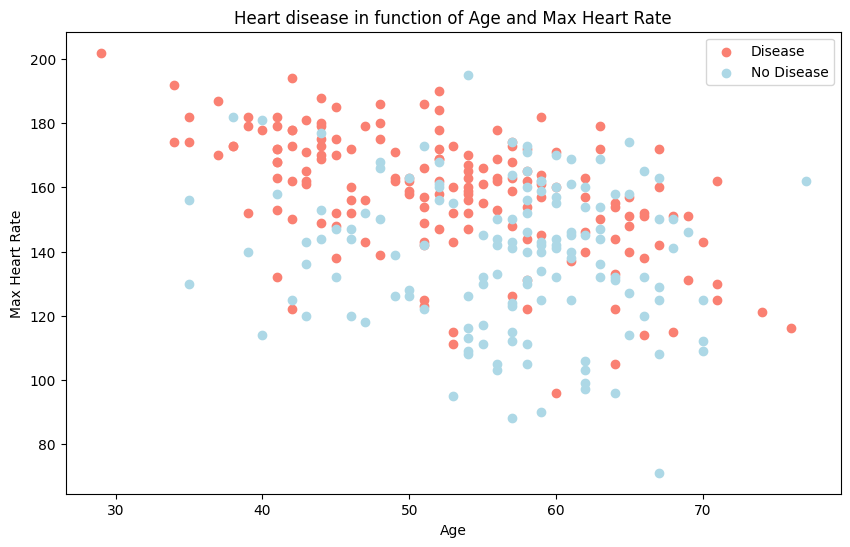

In [12]:
#Scatter plot with just the positive examples
plt.figure(figsize=(10,6))
plt.scatter(df.age[df.target==1],
           df.thalach[df.target==1],
           c="salmon")

#Scatter with negative examples
plt.scatter(df.age[df.target==0],
           df.thalach[df.target==0],
           c="lightblue")

#Add some helpful info
plt.title("Heart disease in function of Age and Max Heart Rate")
plt.xlabel("Age")
plt.ylabel("Max Heart Rate")
plt.legend(["Disease","No Disease"])
plt.show()


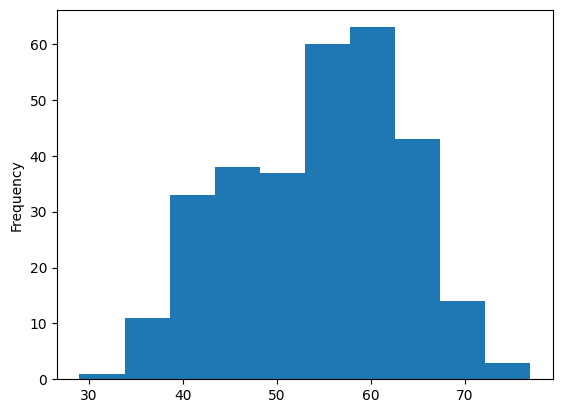

In [13]:
#Check the distribution of the age column with the histogram
df.age.plot.hist(); #Normal distribution - bell curve
plt.show()
#We check distributions to find outliers

### Heart disease frequency per chest pain type
cp chest pain type
- 0. typical angina: chest pain related decrease blood supply to the heart
- 1. atypical angina: chest pain not related to heart
- 2. non-anginal: typically esophaegal spasms (non heart related)
- 3. asymptomatic: chest pain not showing signs of disease


In [14]:
pd.crosstab(df.cp,df.target)

target    0   1
cp             
0       104  39
1         9  41
2        18  69
3         7  16

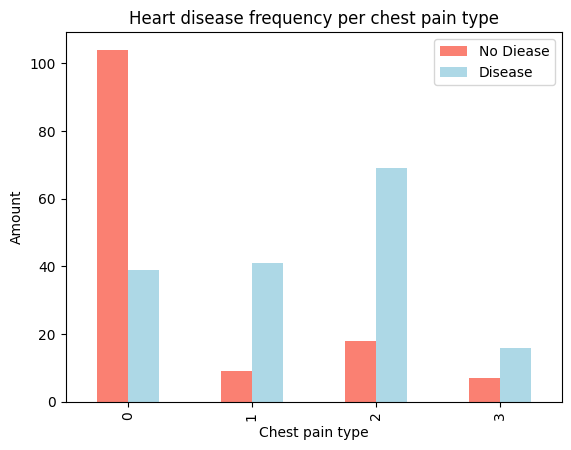

In [15]:
# Make the crosstab more visual
pd.crosstab(df.cp,df.target).plot(kind="bar",color=["salmon","lightblue"])
plt.title("Heart disease frequency per chest pain type")
plt.xlabel("Chest pain type")
plt.ylabel("Amount")
plt.legend(["No Diease","Disease"])
plt.show()

In [16]:
#Check independent vs dependent variables
df.head()

   age  sex  cp  trestbps  chol  fbs  ...  exang  oldpeak  slope  ca  thal  target
0   63    1   3       145   233    1  ...      0      2.3      0   0     1       1
1   37    1   2       130   250    0  ...      0      3.5      0   0     2       1
2   41    0   1       130   204    0  ...      0      1.4      2   0     2       1
3   56    1   1       120   236    0  ...      0      0.8      2   0     2       1
4   57    0   0       120   354    0  ...      1      0.6      2   0     2       1

[5 rows x 14 columns]

In [17]:
#Make a correlation matrix
df.corr()

               age       sex        cp  ...        ca      thal    target
age       1.000000 -0.098447 -0.068653  ...  0.276326  0.068001 -0.225439
sex      -0.098447  1.000000 -0.049353  ...  0.118261  0.210041 -0.280937
cp       -0.068653 -0.049353  1.000000  ... -0.181053 -0.161736  0.433798
trestbps  0.279351 -0.056769  0.047608  ...  0.101389  0.062210 -0.144931
chol      0.213678 -0.197912 -0.076904  ...  0.070511  0.098803 -0.085239
fbs       0.121308  0.045032  0.094444  ...  0.137979 -0.032019 -0.028046
restecg  -0.116211 -0.058196  0.044421  ... -0.072042 -0.011981  0.137230
thalach  -0.398522 -0.044020  0.295762  ... -0.213177 -0.096439  0.421741
exang     0.096801  0.141664 -0.394280  ...  0.115739  0.206754 -0.436757
oldpeak   0.210013  0.096093 -0.149230  ...  0.222682  0.210244 -0.430696
slope    -0.168814 -0.030711  0.119717  ... -0.080155 -0.104764  0.345877
ca        0.276326  0.118261 -0.181053  ...  1.000000  0.151832 -0.391724
thal      0.068001  0.210041 -0.161736

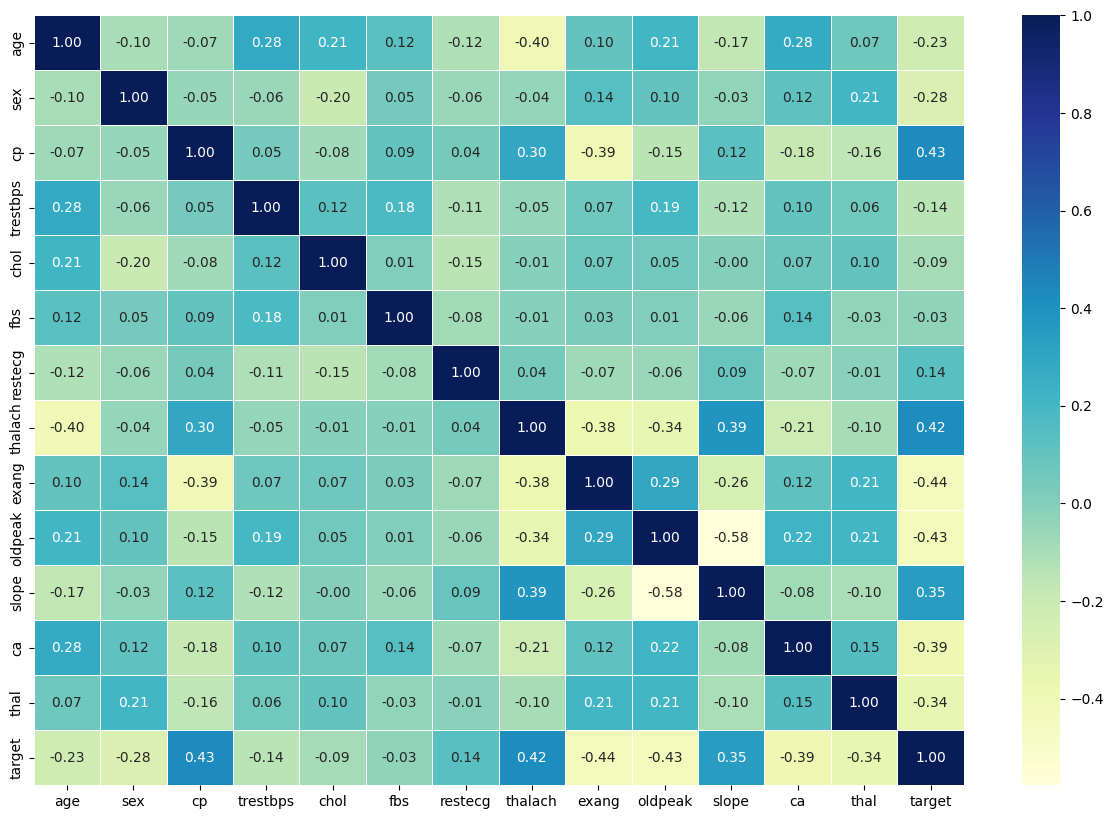

In [18]:
# Make our corelation matrix better using Seaborn
corr_matrix = df.corr()
fig,ax = plt.subplots(figsize=(15,10))
ax = sns.heatmap(corr_matrix,
                annot=True,
                linewidth=0.5,
                fmt=".2f",
                cmap="YlGnBu");
plt.show()

Negative correlation is a relationship between two variables in which one 
variable increases as the other decreases


### 5. Modeling

In [19]:
df.head()

   age  sex  cp  trestbps  chol  fbs  ...  exang  oldpeak  slope  ca  thal  target
0   63    1   3       145   233    1  ...      0      2.3      0   0     1       1
1   37    1   2       130   250    0  ...      0      3.5      0   0     2       1
2   41    0   1       130   204    0  ...      0      1.4      2   0     2       1
3   56    1   1       120   236    0  ...      0      0.8      2   0     2       1
4   57    0   0       120   354    0  ...      1      0.6      2   0     2       1

[5 rows x 14 columns]

In [20]:
#Split into X and y
X = df.drop("target",axis=1)
y = df["target"]

In [21]:
X

     age  sex  cp  trestbps  chol  ...  exang  oldpeak  slope  ca  thal
0     63    1   3       145   233  ...      0      2.3      0   0     1
1     37    1   2       130   250  ...      0      3.5      0   0     2
2     41    0   1       130   204  ...      0      1.4      2   0     2
3     56    1   1       120   236  ...      0      0.8      2   0     2
4     57    0   0       120   354  ...      1      0.6      2   0     2
..   ...  ...  ..       ...   ...  ...    ...      ...    ...  ..   ...
298   57    0   0       140   241  ...      1      0.2      1   0     3
299   45    1   3       110   264  ...      0      1.2      1   0     3
300   68    1   0       144   193  ...      0      3.4      1   2     3
301   57    1   0       130   131  ...      1      1.2      1   1     3
302   57    0   1       130   236  ...      0      0.0      1   1     2

[303 rows x 13 columns]

In [22]:
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

In [23]:
#Split data into train test
np.random.seed(42)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)
model = RandomForestClassifier()

model.fit(X_train,y_train)
score = model.score(X_test,y_test)
print(f"Model accuracy is: {score*100}%")

Model accuracy is: 85.24590163934425%


## Using 3 models to experiment with our data
1. Logistic regression (It is actually a classification model)
2. K Nearest Neighbors
3. Random Forest Classifier

In [24]:
#Put models in a dictionary
models = {"Logistic Regression":LogisticRegression(),
         "KNN":KNeighborsClassifier(),
         "Random Forest":RandomForestClassifier()}

#Create a function to fit and score models
def fit_and_score(models,X_train,X_test,y_train,y_test):
    """ 
    Fit and evaluate different machine learning models
    models: a dict of different sklearn models
    X_train: training data (no labels)
    X_test: testing data (no labels)
    y_train: training labels
    y_test: test labels
    """
    np.random.seed(42)
    model_scores = {}
    for name, model in models.items():
        model.fit(X_train,y_train)
        model_scores[name] = model.score(X_test,y_test)
    return model_scores

In [25]:
model_scores = fit_and_score(models=models,
                             X_train=X_train,
                             X_test=X_test,
                             y_train=y_train,
                             y_test=y_test)
model_scores

/opt/codex/runtimes/codex-primary-runtime/dependencies/python/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Logistic Regression': 0.8852459016393442, 'KNN': 0.6885245901639344, 'Random Forest': 0.8360655737704918}

### Model comparision

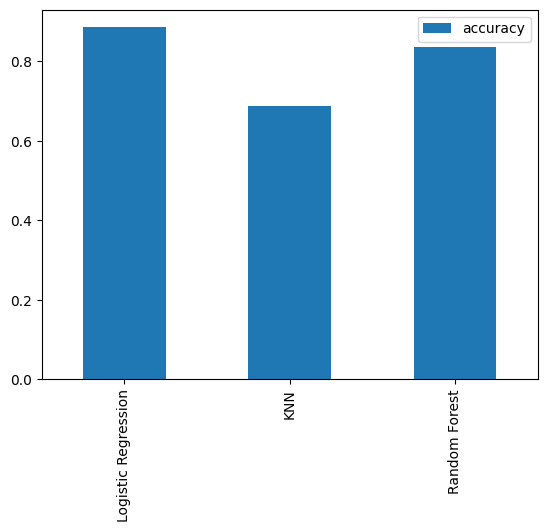

In [26]:
model_compare = pd.DataFrame(model_scores,index=["accuracy"])
model_compare.T.plot.bar();
plt.show()

Basline models are ready, initial predictions made
>Improve model

View the following:
- Hyperparameter tuning
- feature importance
- confusion matrix
- cross validation
- precision
- recall
- f1 score
- classification report
- roc curve
- area under the curve (AUC)


### Hyperparameter tuning

In [27]:
# Tune KNN
train_scores = []
test_scores = []

# Create a list of different values for n-neighbors
neighbors = range(1,21)
knn = KNeighborsClassifier()
for i in neighbors:
    knn.set_params(n_neighbors=i)
    #Fit the algorithm
    knn.fit(X_train,y_train)
    #Update training scores list
    train_scores.append(knn.score(X_train,y_train))

    #Update test scores list
    test_scores.append(knn.score(X_test,y_test))

In [28]:
train_scores

[1.0, 0.8099173553719008, 0.7727272727272727, 0.743801652892562, 0.7603305785123967, 0.7520661157024794, 0.743801652892562, 0.7231404958677686, 0.71900826446281, 0.6942148760330579, 0.7272727272727273, 0.6983471074380165, 0.6900826446280992, 0.6942148760330579, 0.6859504132231405, 0.6735537190082644, 0.6859504132231405, 0.6652892561983471, 0.6818181818181818, 0.6694214876033058]

Max KNN score on test data: 75.41%


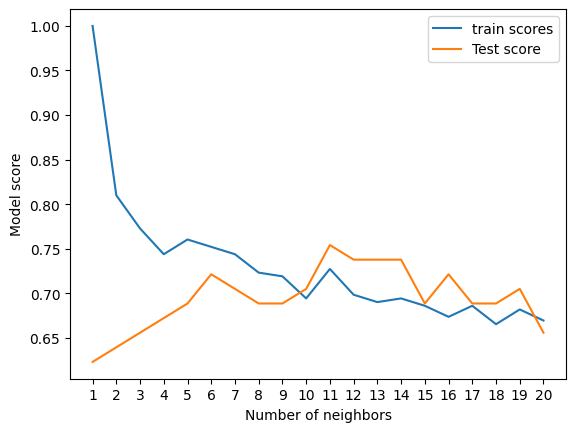

In [29]:
plt.plot(neighbors,train_scores,label="train scores")
plt.plot(neighbors,test_scores,label="Test score")
plt.xticks(np.arange(1,21,1))
plt.xlabel("Number of neighbors")
plt.ylabel("Model score")
plt.legend()
plt.show()

print(f"Max KNN score on test data: {max(test_scores)*100:.2f}%")

## Hyperparameter tuning with randomized search cv
Tune :
- Logistic regression
- random forest classifier
... using randomized search cross validation

In [30]:
#Create a hyperparameter grid for LogisticRegression
log_reg_grid = {"C":np.logspace(-4,4,20),
               "solver":["liblinear"]}

#Create hyperparam grid for random forest classifier
rf_grids = {"n_estimators": np.arange(10,1000,50),
           "max_depth":[None,3,5,10],
           "min_samples_split": np.arange(2,20,2),
           "min_samples_leaf":np.arange(1,20,2)}

Hyperparameter grid setup completed, tune using randomized search cv

In [31]:
#Tune Logistic Regression
np.random.seed(42)

#Setup random hyperparameter search for logistic regression
rs_log_reg = RandomizedSearchCV(LogisticRegression(),
                               param_distributions=log_reg_grid,
                               cv=5,
                               n_iter=20,
                               verbose=True)
#Fit random hyperparameter search model for logistic regression
rs_log_reg.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=LogisticRegression(), n_iter=20,
                   param_distributions={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                                        'solver': ['liblinear']},
                   verbose=True)

In [32]:
rs_log_reg.best_params_

{'solver': 'liblinear', 'C': np.float64(0.23357214690901212)}

In [33]:
rs_log_reg.score(X_test,y_test)

0.8852459016393442

Now we've tuned logisticregression, tune randomforestclassifier next

In [34]:
#Setup random seed
np.random.seed(42)

#Setup random hyperparameter search for randomforestclassifier
rs_rf = RandomizedSearchCV(RandomForestClassifier(),
                            param_distributions=rf_grids,
                          cv=5 ,
                          n_iter=20,
                          verbose=True)
# Fit random hyperparameter search model for randomforestclassifier
rs_rf.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=20,
                   param_distributions={'max_depth': [None, 3, 5, 10],
                                        'min_samples_leaf': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                                        'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14, 16, 18]),
                                        'n_estimators': array([ 10,  60, 110, 160, 210, 260, 310, 360, 410, 460, 510, 560, 610,
       660, 710, 760, 810, 860, 910, 960])},
                   verbose=True)

In [35]:
rs_rf.best_params_

{'n_estimators': np.int64(210), 'min_samples_split': np.int64(4), 'min_samples_leaf': np.int64(19), 'max_depth': 3}

In [36]:
#Evaluate the randomized search random forest classifier
rs_rf.score(X_test,y_test) #This tuned one is still worse than the default

0.8688524590163934

## Grid Search CV to get better results

In [37]:
#different hyperparam for logistic regression model
#search on internet to find best hyperparams
log_reg_grid = {"C":np.logspace(-4,4,30),
               "solver":["liblinear"]}

#Setup grid hyperparameter search for logisticregression
gs_log_reg = GridSearchCV(LogisticRegression(),
                         param_grid=log_reg_grid,
                         cv=5,
                         verbose=True)

#Fit grid hyperparameter search model
gs_log_reg.fit(X_train,y_train);

Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [38]:
#Check best hyperparams
gs_log_reg.best_params_

{'C': np.float64(0.20433597178569415), 'solver': 'liblinear'}

In [39]:
#Evaluate the grid search logistic regression model
gs_log_reg.score(X_test,y_test)


0.8852459016393442

Corrected code:
# Import Seaborn
import seaborn as sns
sns.set(font_scale=1.5) # Increase font size
 
def plot_conf_mat(y_test, y_preds):
    """
    Plots a confusion matrix using Seaborn's heatmap().
    """
    fig, ax = plt.subplots(figsize=(3, 3))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                     annot=True, # Annotate the boxes
                     cbar=False)
    plt.xlabel("Predicted label") # predictions go on the x-axis
    plt.ylabel("True label") # true labels go on the y-axis 
    
plot_conf_mat(y_test, y_preds)


plot_roc_curve is now RocCurveDisplay

## Evaluating tuned ML classifier, beyond just accuracy

+ ROC curve and AUC score
+ confusion matrix
+ classification reprot
+ precision
+ recall
+ F1 score

-- and it would be great if cv was used where possible
to make comparision and evaluate our trained model, first we need to make predictions

In [40]:
#Make predictions with tuned model
y_preds = gs_log_reg.predict(X_test)

In [41]:
y_preds

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [42]:
y_test

179    0
228    0
111    1
246    0
60     1
      ..
249    0
104    1
300    0
193    0
184    0
Name: target, Length: 61, dtype: int64

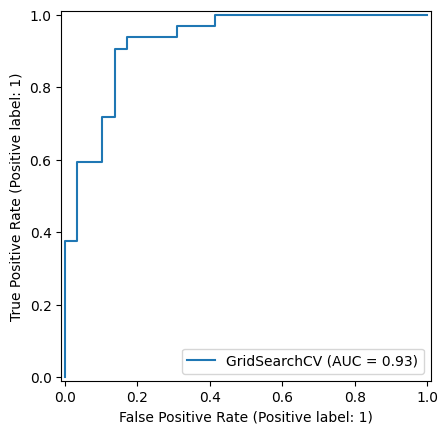

In [43]:
#comparing true positive with false positive using roc curve (refer to confusion matrix)
#import roc curve function from sklearn.metrics
from sklearn.metrics import RocCurveDisplay 
#Plot roc curve and calculate the auc metric
RocCurveDisplay.from_estimator(gs_log_reg, X_test, y_test)
plt.show()

In [44]:
# Confsuion matrix
print(confusion_matrix(y_test,y_preds))

[[25  4]
 [ 3 29]]


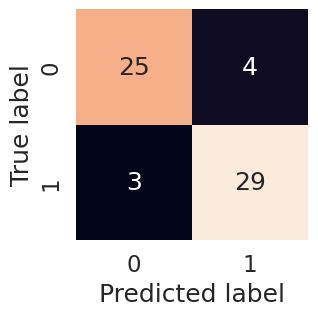

In [45]:
# Import Seaborn
import seaborn as sns
sns.set(font_scale=1.5) # Increase font size
 
def plot_conf_mat(y_test, y_preds):
    """
    Plots a confusion matrix using Seaborn's heatmap().
    """
    fig, ax = plt.subplots(figsize=(3, 3))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                     annot=True, # Annotate the boxes
                     cbar=False)
    plt.xlabel("Predicted label") # predictions go on the x-axis
    plt.ylabel("True label") # true labels go on the y-axis 
    
plot_conf_mat(y_test, y_preds)
plt.show()

Roc_curve and auc metric and a confusion matrix, generate a classification report now
as well as a cv precision recall and f1 score

In [46]:
print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



# Calculate evaluation metrics using cross-validation
calculate accuracy, precision, recall and f1 score of model using cross validation
using `cross-val-score`

In [47]:
# Check best hyperparams
gs_log_reg.best_params_

{'C': np.float64(0.20433597178569415), 'solver': 'liblinear'}

In [48]:
#Create new classifier with best params
clf = LogisticRegression(C=0.20433597178569418,
                        solver="liblinear")

In [49]:
#cross validated accuracy
cv_acc = cross_val_score(clf,X,y,cv=5,scoring="accuracy")
cv_acc

array([0.81967213, 0.90163934, 0.86885246, 0.88333333, 0.75      ])

In [50]:
np.mean(cv_acc)

np.float64(0.8446994535519124)

In [51]:
#cross valiated precision
cv_prec = cross_val_score(clf,X,y,cv=5,scoring="precision")
cv_prec = np.mean(cv_prec)
cv_prec

np.float64(0.8207936507936507)

In [52]:
#cros validated recall
cv_recall = cross_val_score(clf,X,y,cv=5,scoring="recall")
cv_recall = np.mean(cv_recall)
cv_recall

np.float64(0.9212121212121213)

In [53]:
#f1 score
cv_f1 = cross_val_score(clf,X,y,cv=5,scoring="f1")
cv_f1 = np.mean(cv_f1)
cv_f1

np.float64(0.8673007976269721)

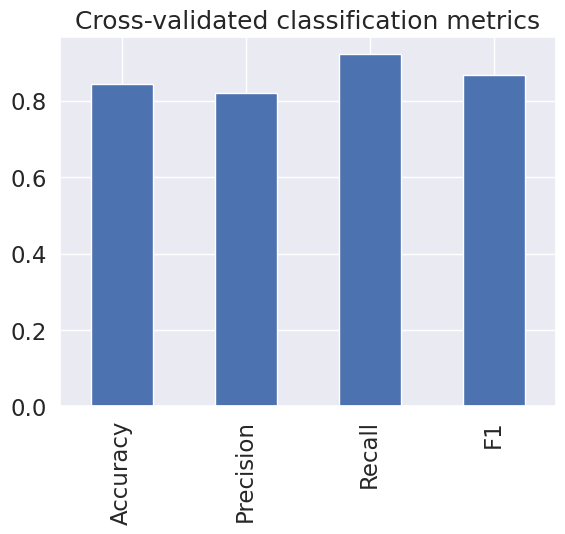

In [54]:
#Visualize cross-validated metrics
cv_metrics = pd.DataFrame({"Accuracy": np.mean(cv_acc),
                         "Precision": cv_prec,
                         "Recall":cv_recall,
                         "F1":cv_f1},
                         index=[0])
cv_metrics.T.plot.bar(title="Cross-validated classification metrics",
                     legend=False)
plt.show()

# Feature Importance
feature importance is another way of asking "which features contributed most to the outcomes
and how did they contribute?"

Finding feature importance is different for each machine learning model

In [55]:
df.head()

   age  sex  cp  trestbps  chol  fbs  ...  exang  oldpeak  slope  ca  thal  target
0   63    1   3       145   233    1  ...      0      2.3      0   0     1       1
1   37    1   2       130   250    0  ...      0      3.5      0   0     2       1
2   41    0   1       130   204    0  ...      0      1.4      2   0     2       1
3   56    1   1       120   236    0  ...      0      0.8      2   0     2       1
4   57    0   0       120   354    0  ...      1      0.6      2   0     2       1

[5 rows x 14 columns]

## Finding feature importance for LogisticRegression model trained earlier

In [56]:
#Fit an instance of LogisticRegression
gs_log_reg.best_params_
clf = LogisticRegression(C=0.20433597178569418,
                        solver="liblinear")
clf.fit(X_train,y_train)

LogisticRegression(C=0.20433597178569418, solver='liblinear')

In [57]:
#Check coef
clf.coef_

array([[ 0.00316728, -0.86044673,  0.66067032, -0.01156993, -0.00166374,
         0.04386101,  0.31275864,  0.02459361, -0.60413094, -0.5686279 ,
         0.45051632, -0.63609907, -0.67663374]])

In [58]:
# Match coef of features to columns
feature_dict = dict(zip(df.columns,list(clf.coef_[0])))
feature_dict

{'age': np.float64(0.003167282794709144), 'sex': np.float64(-0.8604467348902056), 'cp': np.float64(0.6606703189525263), 'trestbps': np.float64(-0.011569932520321466), 'chol': np.float64(-0.0016637445076489463), 'fbs': np.float64(0.04386101102709623), 'restecg': np.float64(0.3127586430963049), 'thalach': np.float64(0.024593614764159985), 'exang': np.float64(-0.604130938845009), 'oldpeak': np.float64(-0.5686278997154095), 'slope': np.float64(0.45051632312010975), 'ca': np.float64(-0.6360990697134957), 'thal': np.float64(-0.6766337424868787)}

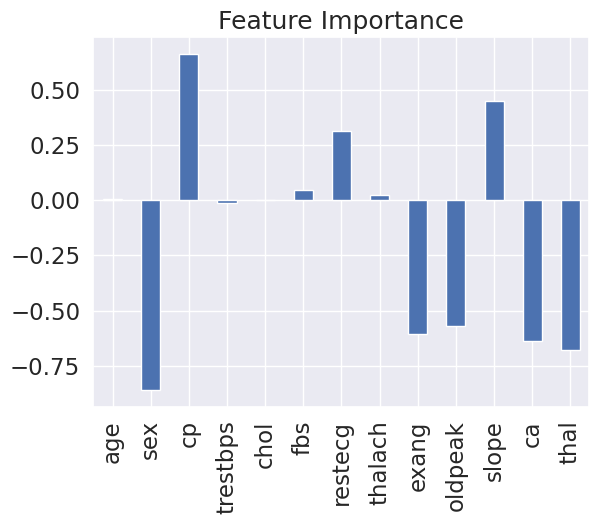

In [59]:
# Visualize feature importance
feature_df = pd.DataFrame(feature_dict,index=[0])
feature_df.T.plot.bar(title="Feature Importance",legend=False)
plt.show()

In [60]:
pd.crosstab(df["sex"],df["target"])

target    0   1
sex            
0        24  72
1       114  93

In [61]:
pd.crosstab(df["slope"],df["target"])

target   0    1
slope          
0       12    9
1       91   49
2       35  107

# Experimentation
If the evaluation metric isnt hit yet then:
1. Could more data be collected?
2. Could a better model be used? like CatBoost or XGBoost
3. Could the model be improved further beyond what has been done?
4. If the model performs good acc. to the eval metric, share it using export.